Phase 1 : Data Preparation & Emotion Mapping  

In [ ]:
pip install torch torchvision sentence-transformers scikit-learn numpy

In [2]:
import pandas as pd

In [3]:
df_songs = pd.read_csv("/content/GPT2_summaries.csv")

In [ ]:
import torch
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from collections import defaultdict

# Initialize models
sbert = SentenceTransformer('all-mpnet-base-v2')  # Pre-trained Sentence-BERT model for semantic embeddings
tfidf = TfidfVectorizer(max_features=10000)  # TF-IDF for extracting important words

def load_vad_lexicon(path="/content/NRC-VAD-Lexicon-v2.1.txt"):
    df = pd.read_csv(path, sep='\t')
    df = df.dropna(subset=['term', 'valence', 'arousal', 'dominance'])
    vad_dict = {
        str(row['term']).lower(): [row['valence'], row['arousal'], row['dominance']]
        for _, row in df.iterrows()
    }
    return vad_dict

def preprocess_summaries(summaries):
    """
    Preprocess song summaries into hybrid embeddings.

    Args:
        summaries (list of str): List of song summaries.

    Returns:
        torch.Tensor: Hybrid embeddings combining SBERT and VAD features.
    """
    # Step 1: Generate SBERT embeddings (768 dimensions)
    print("Generating SBERT embeddings...")
    sbert_embs = sbert.encode(summaries, show_progress_bar=True)

    # Step 2: Compute TF-IDF weighted VAD scores
    print("Computing TF-IDF weighted VAD scores...")
    tfidf_matrix = tfidf.fit_transform(summaries)  # TF-IDF matrix
    vocab = tfidf.get_feature_names_out()  # Vocabulary from TF-IDF
    vad_scores = load_vad_lexicon()  # Load NRC-VAD lexicon

    tfidf_vad = np.zeros((len(summaries), 3))  # Final VAD vector for each summary
    for i, summary in enumerate(summaries):
        words = summary.split()
        vad_sum = np.zeros(3)
        weight_sum = 0.0

        for w in words:
            w_lower = w.lower()
            if w_lower in vocab and w_lower in vad_scores:
                idx = tfidf.vocabulary_[w_lower]
                weight = tfidf_matrix[i, idx]
                vad_vec = np.array(vad_scores[w_lower])

                vad_sum += weight * vad_vec
                weight_sum += weight

        if weight_sum > 0:
            tfidf_vad[i] = vad_sum / weight_sum  # Normalize
        else:
            tfidf_vad[i] = [0.5, 0.5, 0.5]  # Default neutral if no known VAD terms

    # Step 3: Concatenate SBERT embeddings with TF-IDF VAD scores
    hybrid_embs = np.hstack([sbert_embs, tfidf_vad])  # Final feature vector: [SBERT | VAD]

    return torch.tensor(hybrid_embs).float()  # Return as PyTorch tensor


Phase 2 : Emotional VAE

In [5]:
class VA_VAE(torch.nn.Module):
    def __init__(self, input_dim=771, latent_dim=2):
        """
        Variational Autoencoder for Valence-Arousal space.

        Args:
            input_dim (int): Dimensionality of input features.
            latent_dim (int): Dimensionality of latent space (default: 2 for VA space).
        """
        super().__init__()

        # Encoder network
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 512),
            torch.nn.BatchNorm1d(512),
            torch.nn.LeakyReLU(0.2),
            torch.nn.Linear(512, 256),
            torch.nn.LayerNorm(256),
            torch.nn.LeakyReLU(0.2)
        )

        # Latent space parameters
        self.fc_mu = torch.nn.Linear(256, latent_dim)      # Mean of latent distribution
        self.fc_var = torch.nn.Linear(256, latent_dim)     # Log-variance of latent distribution

        # Decoder network
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 256),
            torch.nn.BatchNorm1d(256),
            torch.nn.LeakyReLU(0.2),
            torch.nn.Linear(256, 512),
            torch.nn.LayerNorm(512),
            torch.nn.LeakyReLU(0.2),
            torch.nn.Linear(512, input_dim)
        )

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick to sample from N(mu, var).

        Args:
            mu (torch.Tensor): Mean of latent distribution.
            logvar (torch.Tensor): Log-variance of latent distribution.

        Returns:
            z (torch.Tensor): Sampled latent vector.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        """
        Forward pass through the VAE.

        Args:
            x (torch.Tensor): Input features.

        Returns:
            recon (torch.Tensor): Reconstructed input.
            mu (torch.Tensor): Mean of latent distribution.
            logvar (torch.Tensor): Log-variance of latent distribution.
        """
        hidden = self.encoder(x)       # Encode input to hidden representation
        mu = self.fc_mu(hidden)       # Mean of latent distribution
        logvar = self.fc_var(hidden)  # Log-variance of latent distribution

        z = self.reparameterize(mu, logvar)  # Sample from latent space
        recon = self.decoder(z)              # Decode back to original space

        return recon, mu, logvar

In [6]:
def train_vae(model, data_loader, epochs=100):
    """
    Train the Variational Autoencoder.

    Args:
        model (VA_VAE): The VAE model instance.
        data_loader (DataLoader): DataLoader for training data.
        epochs (int): Number of training epochs.

    Returns:
        None
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        total_loss = 0

        for batch in data_loader:
            batch = batch[0]  # Unpack batch from TensorDataset

            optimizer.zero_grad()

            recon, mu, logvar = model(batch)  # Forward pass

            recon_loss = ((recon - batch)**2).mean()  # Reconstruction loss: MSE between input and reconstructed output

            kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch.size(0)  # KL divergence loss

            loss = recon_loss + kld_loss

            loss.backward()       # Backpropagation
            optimizer.step()      # Update weights

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(data_loader):.4f}")

In [7]:
def map_to_va_space(model, summaries):
    """
    Map new song summaries into VA space.

    Args:
        model (VA_VAE): Trained VAE model.
        summaries (list of str): List of song summaries to map.

    Returns:
        tuple: Mean and variance of VA coordinates for each summary.
    """
    features = preprocess_summaries(summaries)

    with torch.no_grad():
        _, mu, logvar = model(features)

    return mu.numpy(), logvar.exp().numpy()

In [ ]:
# Prepare data loader
features = preprocess_summaries(df_songs['summary'].tolist())
dataset = torch.utils.data.TensorDataset(features)
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

# Train VAE model
vae_model = VA_VAE()
train_vae(vae_model, loader)

In [39]:
torch.save(vae_model.state_dict(), "vae_model.pt")

Generating SBERT embeddings...


Batches:   0%|          | 0/186 [00:00<?, ?it/s]

Computing TF-IDF weighted VAD scores...


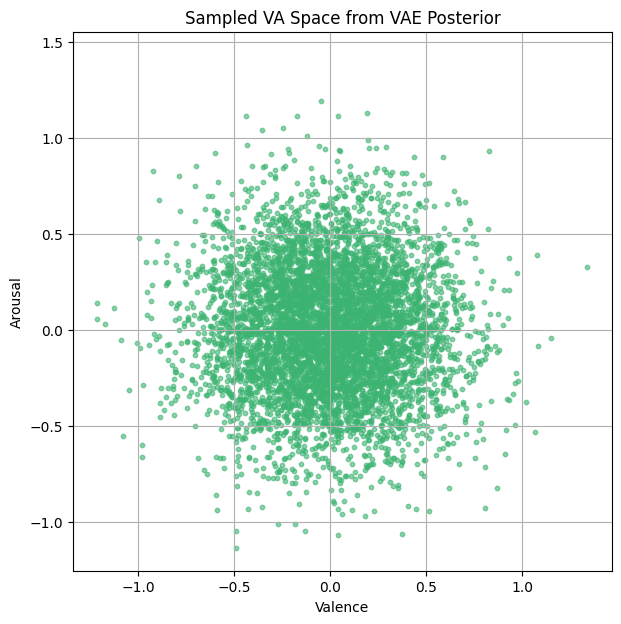

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def plot_sampled_va_space_from_vae(df_summary, vae_model, map_to_va_space_fn, scale=0.2):
    summaries = df_summary['summary'].tolist()

    # Get VAE posterior parameters
    mu, logvar = map_to_va_space_fn(vae_model, summaries)

    # Sample from each distribution
    std = np.exp(0.5 * logvar)
    eps = np.random.randn(*std.shape)
    z = mu + scale * eps * std  # sample from N(mu, sigma)

    # Clip to valid VA range
    va_points = z

    # Plot
    plt.figure(figsize=(7, 7))
    plt.scatter(va_points[:, 0], va_points[:, 1], alpha=0.6, c='mediumseagreen', s=10)
    plt.xlabel("Valence")
    plt.ylabel("Arousal")
    plt.title("Sampled VA Space from VAE Posterior")
    plt.grid(True)
    plt.axis('square')
    plt.show()
plot_sampled_va_space_from_vae(df_songs, vae_model, map_to_va_space)

Phase 3 : USER MOOD MODELLING

In [10]:
import json
import pandas as pd

def extract_playlists_from_challenge_set(
    challenge_json_path,
    summary_csv_path,
    NUM_PLAYLISTS=1000,
    MIN_SEQ_LEN=4
):
    """
    Extracts up to NUM_PLAYLISTS from challenge_set.json where songs are present in the summary dataset.

    Args:
        challenge_json_path (str): Path to challenge_set.json
        summary_csv_path (str): Path to GPT2 summary CSV (with 'title' column)
        NUM_PLAYLISTS (int): Number of valid playlists to extract
        MIN_SEQ_LEN (int): Minimum number of matched songs in a playlist

    Returns:
        List[List[str]]: Filtered valid playlists of song titles
    """
    with open(challenge_json_path, 'r', encoding='utf-8') as f:
        challenge_data = json.load(f)

    df_summary = pd.read_csv(summary_csv_path)
    summary_titles = set(df_summary['title'].str.lower().str.strip())

    valid_playlists = []
    for playlist in challenge_data['playlists']:
        track_titles = [t['track_name'].lower().strip() for t in playlist['tracks']]
        matched_titles = [t for t in track_titles if t in summary_titles]

        if len(matched_titles) >= MIN_SEQ_LEN:
            valid_playlists.append(matched_titles)

        if len(valid_playlists) >= NUM_PLAYLISTS:
            print(f"✅ Collected {NUM_PLAYLISTS} valid playlists. Done.")
            break

    return valid_playlists


In [11]:
playlists = extract_playlists_from_challenge_set(
    challenge_json_path='/content/challenge_set.json',
    summary_csv_path='/content/GPT2_summaries.csv',
    NUM_PLAYLISTS=2000,
    MIN_SEQ_LEN=6
)

In [12]:
len(playlists)

1035

In [13]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.9/165.9 kB 4.3 MB/s eta 0:00:00


In [14]:
import torch
import pandas as pd
import numpy as np
from typing import List
from tqdm import tqdm
from hmmlearn.hmm import GaussianHMM
from sklearn.model_selection import train_test_split
from hmmlearn.hmm import GaussianHMM
from sklearn.cluster import KMeans
import numpy as np

# STEP 1: Build VA sequences from playlists using VAE sampling
def build_sampled_va_sequences(playlists: List[List[str]],
                                df_summary: pd.DataFrame,
                                vae_model,
                                map_to_va_space_fn) -> List[np.ndarray]:
    title_to_summary = {
        row['title'].strip().lower(): row['summary']
        for _, row in df_summary.iterrows()
    }

    va_sequences = []
    for playlist in tqdm(playlists, desc="Sampling VA sequences"):
        summaries = []
        for title in playlist:
            key = title.strip().lower()
            if key in title_to_summary:
                summaries.append(title_to_summary[key])

        if len(summaries) >= 2:
            mu, logvar = map_to_va_space_fn(vae_model, summaries)
            std = np.exp(0.5 * logvar)
            eps = np.random.randn(*std.shape)
            z = mu + 0.2 *eps * std  # Sample from latent VA space
            va_sequences.append(z)

    return va_sequences


# STEP 2: Train Gaussian HMM on sampled VA sequences
def train_hmm_with_kmeans_init(va_sequences, n_states=9):
    all_data = np.vstack(va_sequences)
    lengths = [len(seq) for seq in va_sequences]

    # Step 1: Cluster VA space
    kmeans = KMeans(n_clusters=n_states, random_state=42).fit(all_data)
    initial_means = kmeans.cluster_centers_
    print(initial_means)

    # Step 2: Fit HMM with those centers as initial means
    model = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=450, init_params="stmc")
    model.startprob_ = np.full(n_states, 1.0 / n_states)  # uniform start prob
    model.transmat_ = np.full((n_states, n_states), 1.0 / n_states)  # uniform transitions
    model.means_ = initial_means
    model.fit(all_data, lengths=lengths)

    return model


# STEP 3: Predict next VA vector using the trained HMM
def predict_next_va(model, va_sequence):
    posterior = model.predict_proba(va_sequence)
    return np.sum(posterior[-1][:, None] * model.means_, axis=0)

In [15]:
def next_va_prediction_error(model, test_sequences):
    errors = []
    for seq in test_sequences:
        if len(seq) < 3:
            continue
        predicted = predict_next_va(model, seq[:-1])
        actual = seq[-1]
        error = np.linalg.norm(predicted - actual)
        errors.append(error)
    return np.mean(errors)

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
loaded = np.load("sampled_va_sequences.npz", allow_pickle=True)
sampled_va_sequences = [loaded[key] for key in loaded]
flat = np.vstack(sampled_va_sequences)
scaler.fit(flat)
normalized_sequences = [scaler.transform(seq) for seq in sampled_va_sequences]
from sklearn.model_selection import train_test_split
train_seq, test_seq = train_test_split(normalized_sequences, test_size=0.2, random_state=42)

In [17]:
hmm_model = train_hmm_with_kmeans_init(train_seq, n_states=10)
epsilon = 1e-2
n = hmm_model.n_components
hmm_model.transmat_ = hmm_model.transmat_ * (1 - epsilon) + (epsilon / n)
avg_error = next_va_prediction_error(hmm_model, test_seq)
print(f"Normalized average error: {avg_error:.4f}")

[[0.29413543 0.43331927]
 [0.5113724  0.61046646]
 [0.33151119 0.61159518]
 [0.43959796 0.48621783]
 [0.57224751 0.49242191]
 [0.43679378 0.74561466]
 [0.70122426 0.39441674]
 [0.48582046 0.32549852]
 [0.7053005  0.58536443]
 [0.61742333 0.73754054]]
Normalized average error: 0.1677


In [18]:
print(hmm_model.means_)  # shape (n_states, 2)

[[0.46142391 0.55469968]
 [0.47689153 0.49826606]
 [0.33225926 0.6289337 ]
 [0.61147479 0.52885134]
 [0.60221555 0.55335978]
 [0.54002363 0.52226186]
 [0.49336913 0.51989399]
 [0.62702213 0.58324481]
 [0.46771291 0.64295004]
 [0.56415895 0.47197944]]


In [20]:
from collections import Counter
# Check which states are being predicted
state_counts = Counter()
for seq in test_seq:
    if len(seq) >= 3:
        _, states = hmm_model.decode(seq[:-1], algorithm="viterbi")
        state_counts.update(states)

print(state_counts)

Counter({np.int64(6): 706, np.int64(0): 159, np.int64(1): 128, np.int64(8): 119, np.int64(9): 107, np.int64(5): 99, np.int64(4): 82, np.int64(3): 69, np.int64(2): 20, np.int64(7): 14})


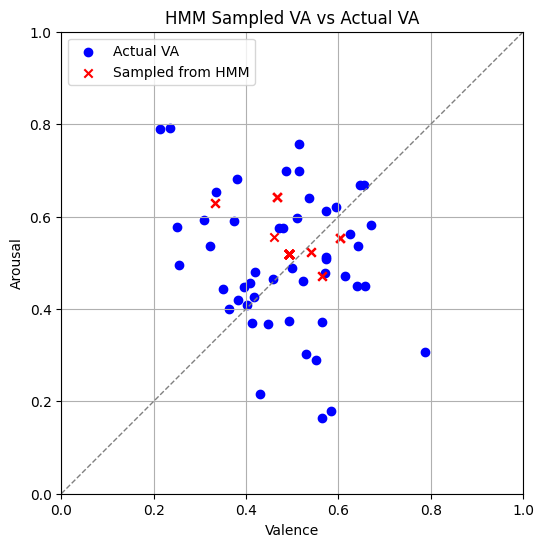

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hmm_sampled_vs_actual_va(test_sequences, hmm_model, num_points=50):
    actual_vas = []
    sampled_vas = []

    count = 0
    for seq in test_sequences:
        if len(seq) < 3:
            continue

        actual_va = seq[-1]
        _, states = hmm_model.decode(seq[:-1], algorithm="viterbi")
        last_state = states[-1]

        mean = hmm_model.means_[last_state]
        cov = hmm_model.covars_[last_state]
        sampled_va = mean

        actual_vas.append(actual_va)
        sampled_vas.append(sampled_va)

        count += 1
        if count >= num_points:
            break

    actual_vas = np.array(actual_vas)
    sampled_vas = np.array(sampled_vas)

    plt.figure(figsize=(6, 6))
    plt.scatter(actual_vas[:, 0], actual_vas[:, 1], c='blue', label='Actual VA')
    plt.scatter(sampled_vas[:, 0], sampled_vas[:, 1], c='red', label='Sampled from HMM', marker='x')
    plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
    plt.xlabel('Valence')
    plt.ylabel('Arousal')
    plt.title('HMM Sampled VA vs Actual VA')
    plt.legend()
    plt.grid(True)
    plt.axis('square')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

plot_hmm_sampled_vs_actual_va(test_seq, hmm_model, num_points=50)

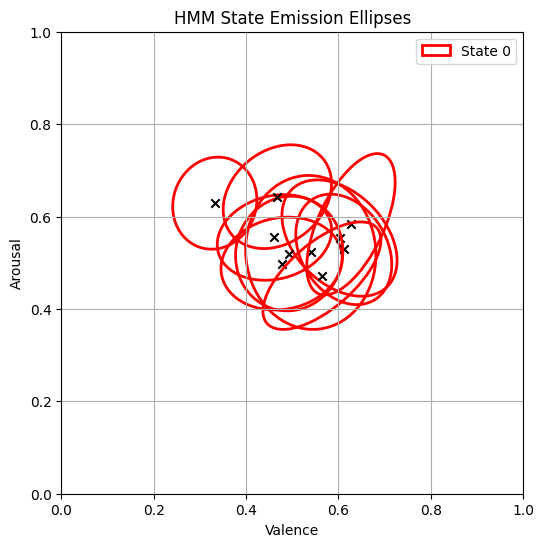

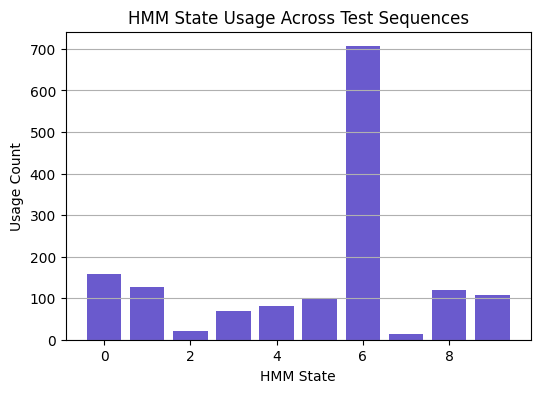

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from collections import Counter
from tqdm import tqdm

# 2. Plot HMM ellipses for state emission Gaussians
def plot_hmm_state_ellipses(hmm_model):
    plt.figure(figsize=(6, 6))

    for i, (mean, cov) in enumerate(zip(hmm_model.means_, hmm_model.covars_)):
        if cov.shape == (2, 2):  # full covariance
            vals, vecs = np.linalg.eigh(cov)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
            width, height = 2 * np.sqrt(vals)
            ellipse = Ellipse(xy=mean, width=width, height=height, angle=theta,
                              edgecolor='red', fc='none', lw=2, label=f'State {i}' if i == 0 else None)
            plt.gca().add_patch(ellipse)
        else:
            # diag case
            width, height = 2 * np.sqrt(cov)
            ellipse = Ellipse(xy=mean, width=width, height=height, angle=0,
                              edgecolor='red', fc='none', lw=2, label=f'State {i}' if i == 0 else None)
            plt.gca().add_patch(ellipse)

        plt.scatter(mean[0], mean[1], c='black', marker='x')

    plt.title("HMM State Emission Ellipses")
    plt.xlabel("Valence")
    plt.ylabel("Arousal")
    plt.legend()
    plt.grid(True)
    plt.axis('square')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

plot_hmm_state_ellipses(hmm_model)

def plot_hmm_state_usage(test_sequences, hmm_model):
    state_counts = Counter()
    for seq in test_sequences:
        if len(seq) >= 3:
            _, states = hmm_model.decode(seq[:-1], algorithm="viterbi")
            state_counts.update(states)

    states, counts = zip(*sorted(state_counts.items()))
    plt.figure(figsize=(6, 4))
    plt.bar(states, counts, color='slateblue')
    plt.xlabel("HMM State")
    plt.ylabel("Usage Count")
    plt.title("HMM State Usage Across Test Sequences")
    plt.grid(True, axis='y')
    plt.show()
plot_hmm_state_usage(test_seq, hmm_model)

In [37]:
import pickle

# 🔽 Save HMM
with open("hmm_model.pkl", "wb") as f:
    pickle.dump(hmm_model, f)

Phase 4 : Recommender system

In [ ]:
from collections import Counter
import numpy as np

# Get all summaries and titles
all_summaries = df_songs['summary'].tolist()
all_titles = df_songs['title'].tolist()

mu, logvar = map_to_va_space(vae_model, all_summaries)

std = np.exp(0.5 * logvar)
eps = np.random.randn(*std.shape)
z = mu + 0.2 * eps * std  # sample from N(mu, sigma)

In [64]:
mu_normalized = scaler.transform(z)

# Step 0.3: Build required dictionaries
title_to_va = {title.lower(): va for title, va in zip(all_titles, mu_normalized)}
title_freq = Counter(song.lower() for playlist in playlists for song in playlist)

In [65]:
def ensemble_feature_extract(predicted_va, current_va, song_va, freq_score):
    return np.array([
        -np.linalg.norm(song_va - predicted_va),      # Emotion match
        -np.linalg.norm(song_va - current_va),        # Closeness to current mood
        freq_score,                                   # Popularity
        np.linalg.norm(song_va - predicted_va)        # Diversity booster
    ])

In [66]:
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

def train_ensemble_linear_model(train_sequences, hmm_model, title_to_va, title_freq):
    X, y = [], []

    for seq in tqdm(train_sequences, desc="Training ensemble"):
        if len(seq) < 3:
            continue

        current_va = seq[-2]
        actual_va = seq[-1]
        predicted_va = predict_next_va(hmm_model, seq[:-1])  # HMM prediction

        for title, song_va in title_to_va.items():
            freq_score = title_freq.get(title, 0)
            features = ensemble_feature_extract(predicted_va, current_va, song_va, freq_score)
            X.append(features)
            y.append(actual_va)

    model = LinearRegression()
    model.fit(X, y)
    return model

In [67]:
def recommend_top_k_va(ensemble_model, predicted_va, current_va, title_to_va, title_freq, k=3):
    scores = []

    for title, song_va in title_to_va.items():
        freq_score = title_freq.get(title, 0)
        features = ensemble_feature_extract(predicted_va, current_va, song_va, freq_score)
        va_pred = ensemble_model.predict([features])[0]
        scores.append((title, va_pred))

    dists = [(title, np.linalg.norm(predicted_va - va_pred)) for title, va_pred in scores]
    return sorted(dists, key=lambda x: x[1])[:k]


In [68]:
def evaluate_ensemble_on_test(test_sequences, hmm_model, title_to_va, title_freq, ensemble_model):
    errors = []

    for seq in tqdm(test_sequences, desc="Evaluating ensemble"):
        if len(seq) < 3:
            continue

        current_va = seq[-2]
        actual_va = seq[-1]
        predicted_va = predict_next_va(hmm_model, seq[:-1])

        va_preds = []
        for title, song_va in title_to_va.items():
            freq_score = title_freq.get(title, 0)
            features = ensemble_feature_extract(predicted_va, current_va, song_va, freq_score)
            va_pred = ensemble_model.predict([features])[0]
            va_preds.append(va_pred)

        avg_va = np.mean(va_preds, axis=0)
        error = np.linalg.norm(avg_va - actual_va)
        errors.append(error)

    return np.mean(errors)

In [69]:
# Train ensemble model
ensemble_model = train_ensemble_linear_model(train_seq, hmm_model, title_to_va, title_freq)

# Evaluate
avg_va_error = evaluate_ensemble_on_test(test_seq, hmm_model, title_to_va, title_freq, ensemble_model)
print(f"\n📏 Average VA-space error from ensemble: {avg_va_error:.4f}")


Evaluating ensemble: 100%|██████████| 207/207 [02:33<00:00,  1.34it/s]


📏 Average VA-space error from ensemble: 0.1657


In [70]:
# Recommend on a test playlist
test_sequence = test_seq[0]
predicted_va = predict_next_va(hmm_model, test_sequence[:-1])
current_va = test_seq[-2]

top_3_recs = recommend_top_k_va(ensemble_model, predicted_va, current_va, title_to_va, title_freq, k=3)
print("\n🎧 Top 3 Song Recommendations:")
for title, dist in top_3_recs:
    print(f"{title}  (VA distance = {dist:.4f})")


🎧 Top 3 Song Recommendations:
musicians who owned a part of sports teams  (VA distance = 0.0444)
reason 41  (VA distance = 0.0479)
classic diss  (VA distance = 0.0494)


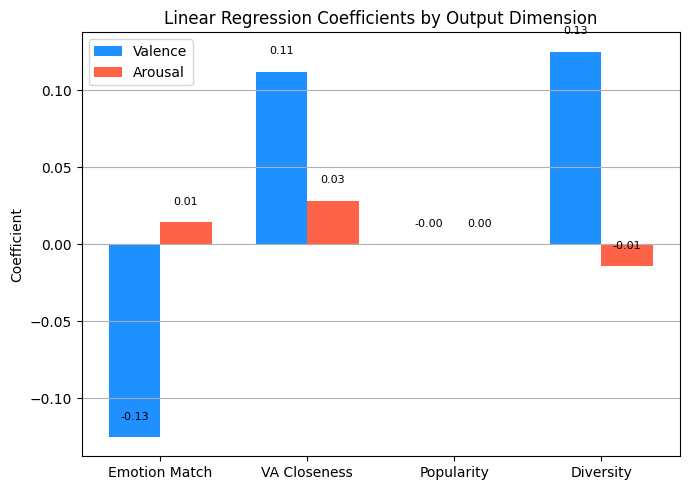

In [74]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ensemble_feature_importance(ensemble_model):
    feature_names = ["Emotion Match", "VA Closeness", "Popularity", "Diversity"]

    if hasattr(ensemble_model, 'coef_') and ensemble_model.coef_.ndim == 2:
        valence_coefs = ensemble_model.coef_[0]
        arousal_coefs = ensemble_model.coef_[1]
        x = np.arange(len(feature_names))

        width = 0.35
        plt.figure(figsize=(7, 5))
        bars1 = plt.bar(x - width/2, valence_coefs, width, label='Valence', color='dodgerblue')
        bars2 = plt.bar(x + width/2, arousal_coefs, width, label='Arousal', color='tomato')

        plt.xticks(x, feature_names)
        plt.ylabel("Coefficient")
        plt.title("Linear Regression Coefficients by Output Dimension")
        plt.legend()
        plt.grid(True, axis='y')

        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
                         f"{height:.2f}", ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Expected LinearRegression model with 2D output coefficients.")
plot_ensemble_feature_importance(ensemble_model)

In [38]:
with open("ensemble_model.pkl", "wb") as f:
    pickle.dump(ensemble_model, f)